# Liar's Poker: a runnable map

This notebook follows the path from a `GameSpec` to a playable policy and then to evaluation. Run top to bottom from the repository's `.venv` kernel. Default cells do **not** start a GPU training run or an approximate best responder. Figures read existing artifacts; the tiny exact solve is deliberately cheap.

The four landmarks are small tabular games, the 18-claim neural test game, the 30-claim intermediate game, and the 69-claim scaling game. Claim count is not the whole game size: private hands, history, and chance also matter.

In [4]:
from pathlib import Path
import json
import sys
import zipfile

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'liars_poker' / 'core.py').exists())
sys.path.insert(0, str(ROOT))
from liars_poker.core import GameSpec, possible_starting_hands
from liars_poker.env import Env, rules_for_spec
from liars_poker.infoset import CALL, InfoSet
from liars_poker.policies.neural import InfosetEncoder
from liars_poker.algo.cfr_plus_dense import CFRPlusDense
from liars_poker.algo.br_exact_dense_to_dense import best_response_dense
from liars_poker.serialization import load_policy

def read_jsonl(path):
    return pd.DataFrame(json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip())

print('Repository:', ROOT)

Repository: c:\Users\adidh\Documents\liars_poker


## 1. Rules, hidden information, and infosets

`core.py` defines the deck and `GameSpec`. `env.py` builds ordered claims, legal raises, calls, and their truth conditions. `Env` deals disjoint hands, but a policy sees only its own hand and the public claim history through `InfoSet(pid, hand, history)`. Suit symmetry collapses equivalent private hands. The current code supports six claim families through Quads; the larger proposed 368-claim game is **not** implemented here.

In [5]:
SPECS = {
    'small tabular 18': GameSpec(4, 4, 4, ('RankHigh', 'Pair', 'TwoPair', 'Trips'), True),
    'neural 18': GameSpec(4, 4, 2, ('RankHigh', 'Pair', 'TwoPair', 'Trips'), True),
    'intermediate 30': GameSpec(5, 4, 3, ('RankHigh', 'Pair', 'TwoPair', 'Trips', 'Quads'), True),
    'scaling 69': GameSpec(6, 4, 4, ('RankHigh', 'Pair', 'TwoPair', 'Trips', 'FullHouse', 'Quads'), True),
}
display(pd.DataFrame([{'game': name, 'spec': spec.to_short_str(),
                       'claims': len(rules_for_spec(spec).claims),
                       'private hand types': len(possible_starting_hands(spec)),
                       'evaluation': 'exact feasible' if '18' in name else 'approximate BR'}
                      for name, spec in SPECS.items()]))

,game,spec,claims,private hand types,evaluation
0,small tabular 18,r4_s4_h4_hp2pt_ss,18,35,exact feasible
1,neural 18,r4_s4_h2_hp2pt_ss,18,10,exact feasible
2,intermediate 30,r5_s4_h3_hp2ptq_ss,30,35,approximate BR
3,scaling 69,r6_s4_h4_hp2ptfhq_ss,69,126,approximate BR


In [6]:
spec = SPECS['neural 18']
env = Env(spec)
opening = env.reset(seed=7)
claim = opening['legal_actions'][0]
reply = env.step(claim)
finish = env.step(CALL)
display(pd.DataFrame([
    {'turn': 'P1 observes', 'private hand': opening['hand'], 'public history': opening['history'], 'result': ''},
    {'turn': 'P2 sees ' + env.render_action(claim), 'private hand': reply['hand'], 'public history': reply['history'], 'result': ''},
    {'turn': 'P2 calls', 'private hand': finish['hand'], 'public history': finish['history'], 'result': finish['winner']},
]))
infoset = opening['infoset_key']
encoder = InfosetEncoder(spec)
print('Opening infoset:', infoset)
print('Neural input:', encoder.encode(infoset.hand, infoset.history), '(hand counts + public claim bits)')

,turn,private hand,public history,result
0,P1 observes,"(1, 4)",(),
1,P2 sees RankHigh:1,"(2, 3)","(0,)",
2,P2 calls,"(2, 3)","(0, -1)",P1


Opening infoset: InfoSet(pid=0, hand=(1, 4), history=())
Neural input: [1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] (hand counts + public claim bits)


## 2. Exact tabular path

`algo/cfr_plus_dense.py` stores nonnegative regrets and a linearly weighted average strategy at each infoset. `algo/br_exact_dense_to_dense.py` computes a genuine best response on small enough games. The exploitability convention in this repo is `P(win as first against policy) + P(win as second against policy) - 1`; zero is equilibrium. The tiny example below exercises the same interfaces as the larger tabular benchmark without allocating its much larger tables.

In [7]:
tiny = GameSpec(2, 2, 1, ('RankHigh', 'Pair'), True)
solver = CFRPlusDense(tiny)
for _ in range(30):
    solver.iterate()
tiny_policy = solver.average_policy()
_, br_result = best_response_dense(tiny, tiny_policy, store_state_values=False)
p_first, p_second = br_result['computer'].exploitability()
print(f'{solver.iteration} iterations; exact BR win probabilities: {p_first:.4f}, {p_second:.4f}')
print(f'Exact exploitability: {p_first + p_second - 1:.5f}')

30 iterations; exact BR win probabilities: 0.6674, 0.4157
Exact exploitability: 0.08303


In [8]:
benchmark = ROOT / 'artifacts/benchmark_runs/cfr_plus_runs/r4_s4_h4_hp2pt_ss___20260108-192548/metrics.json'
if benchmark.exists():
    final = json.loads(benchmark.read_text(encoding='utf-8'))['exploitability_series'][-1]
    print('Saved tabular 18 benchmark:', final['iter'], 'iterations;',
          'exact exploitability', round(final['p_first'] + final['p_second'] - 1, 6))

Saved tabular 18 benchmark: 9050 iterations; exact exploitability 0.000911


## 3. Neural CFR+ path

`algo/deep_cfr_plus.py` is the trainer: each iteration collects traversal records, fits regret networks, and fits an average-strategy network. `algo/neural_cfr_plus_gpu.py` handles batched GPU traversal, action sampling, and optional chunked expansion. `policies/neural_regret.py` turns current regrets into a current strategy; `policies/neural.py` holds the playable average network. `training/neural_runs.py` and `scripts/` orchestrate runs and snapshots. The average policy is normally what we deploy.

`serialization.py` loads a **policy** for play/evaluation. A trainer `.pt` checkpoint instead includes optimizer and replay state for resuming training. They are different artifacts.

In [9]:
POLICIES = {
    'tabular 18': ROOT / 'artifacts/benchmark_runs/cfr_plus_runs/r4_s4_h4_hp2pt_ss___20260108-192548/policy',
    'neural 30': ROOT / 'artifacts/cfr_plus_30_claim_lr_schedule_screen/r5_s4_h3_hp2ptq_ss___20260626-003941/aggressive_moderate_40/seed_17/final_policy',
    'neural 69 (adaptive 120m)': ROOT / 'artifacts/cfr_plus_69_claim_adaptive/r6_s4_h4_hp2ptfhq_ss___20260628-095411/policy_snapshots/0120m/average_policy',
}
for label, path in POLICIES.items():
    if not path.exists():
        print(label, ': not present locally')
        continue
    policy, loaded_spec = load_policy(str(path))
    hand = possible_starting_hands(loaded_spec)[0]
    probs = policy.action_probs(InfoSet(pid=0, hand=hand, history=()))
    rules = rules_for_spec(loaded_spec)
    top = sorted(probs.items(), key=lambda item: item[1], reverse=True)[:3]
    print(label, type(policy).__name__, loaded_spec.to_short_str(), 'hand', hand)
    print('  opening actions:', [(rules.render_action(a), round(float(p), 3)) for a, p in top])

tabular 18 DenseTabularPolicy r4_s4_h4_hp2pt_ss hand (1, 1, 1, 1)
  opening actions: [('Trips:1', 0.987), ('Pair:1', 0.007), ('Pair:4', 0.004)]
neural 30 NeuralPolicy r5_s4_h3_hp2ptq_ss hand (1, 1, 1)
  opening actions: [('Trips:1', 0.309), ('Pair:1', 0.177), ('RankHigh:1', 0.153)]
neural 69 (adaptive 120m) NeuralPolicy r6_s4_h4_hp2ptfhq_ss hand (1, 1, 1, 1)
  opening actions: [('Trips:1', 0.971), ('RankHigh:6', 0.008), ('RankHigh:2', 0.005)]


## 4. Evaluation: exact versus discovered BR

For small games, compile a neural policy to a dense policy (`eval/neural_evaluators.py`) and compute exact BR. For 30 and 69 claims, train an approximate action-conditioned complete-return responder (`algo/br_fitted_return.py`, `training/br_runs.py`), then estimate its win rates by Monte Carlo (`eval/approx_br.py`). These numbers are **discovered lower bounds on true exploitability**, not proofs of closeness to equilibrium. The reported confidence interval covers Monte Carlo evaluation noise, not responder optimization error. Compare policies only at the same responder method, training budget, and evaluation settings.

,method,training min represented,iterations represented,final exploitability,best exploitability,normalized AUC over own horizon
0,Deep CFR reference,45.005647,1834,0.083651,0.081524,0.086474
1,Neural CFR+ old reference (100/50),45.019992,1699,0.034355,0.034355,0.052487
2,Neural CFR+ optimized reference (24/6),45.004789,7593,0.024108,0.024108,0.032404


,schedule_name,snapshot_target_min,exploitability_estimate
4,aggressive_moderate_40,50.0,0.015350
5,aggressive_moderate_40,60.0,0.022920
16,smooth_cosine_1e3_to_1e4,50.0,0.024895
11,normal_late_drop_constant,60.0,0.027090
17,smooth_cosine_1e3_to_1e4,60.0,0.028110
15,smooth_cosine_1e3_to_1e4,40.0,0.029235
21,very_aggressive_20_40,40.0,0.029385
9,normal_late_drop_constant,40.0,0.030135
10,normal_late_drop_constant,50.0,0.030530
2,aggressive_moderate_40,30.0,0.032590


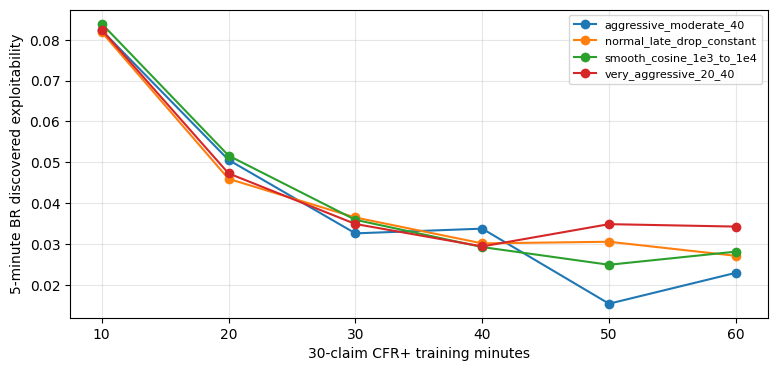

In [10]:
reference = ROOT / 'artifacts/deep_cfr_plus_reference_runs/r4_s4_h2_hp2pt_ss___optimized_24r6s___20260621-201555/reference_comparison.csv'
if reference.exists():
    display(pd.read_csv(reference))
thirty = ROOT / 'artifacts/cfr_plus_30_claim_lr_schedule_screen/r5_s4_h3_hp2ptq_ss___20260626-003941/br_evaluations.jsonl'
if thirty.exists():
    br30 = read_jsonl(thirty)
    final5 = br30.loc[br30['responder_training_min'].between(4.9, 5.2)]
    display(final5.groupby(['schedule_name', 'snapshot_target_min'], as_index=False)['exploitability_estimate'].max().sort_values('exploitability_estimate').head(12))
    fig, ax = plt.subplots(figsize=(9, 4))
    for name, rows in final5.groupby('schedule_name'):
        curve = rows.groupby('snapshot_target_min')['exploitability_estimate'].max()
        ax.plot(curve.index, curve.values, marker='o', label=name)
    ax.set(xlabel='30-claim CFR+ training minutes', ylabel='5-minute BR discovered exploitability')
    ax.legend(fontsize=8); ax.grid(alpha=.3); plt.show()

,target min,responder training min,best discovered estimate,conservative lower bound
0,200.0,60.005662,0.300665,0.296480
1,400.0,60.002139,0.282185,0.277975
2,720.0,60.039433,0.300650,0.296464


,measured_training_min,br_total_target_min,decision_estimate,phase_name
24,195.012913,2.0,0.206185,p1_lr_1e-3_trav1024_cap24
26,210.008191,10.0,0.214710,p1_lr_1e-3_trav1024_cap24
28,225.013423,2.0,0.203090,p1_lr_1e-3_trav1024_cap24
30,240.000089,10.0,0.212015,p1_lr_1e-3_trav1024_cap24
32,255.000102,2.0,0.211710,p2_lr_3e-4_trav1024_cap24
34,270.010530,10.0,0.195120,p2_lr_3e-4_trav1024_cap24
36,285.005739,2.0,0.207865,p2_lr_3e-4_trav1024_cap24
38,300.001084,10.0,0.210025,p2_lr_3e-4_trav1024_cap24
40,315.011722,2.0,0.207050,p3_lr_1e-4_trav2048_cap24
42,330.019098,10.0,0.202965,p3_lr_1e-4_trav2048_cap24


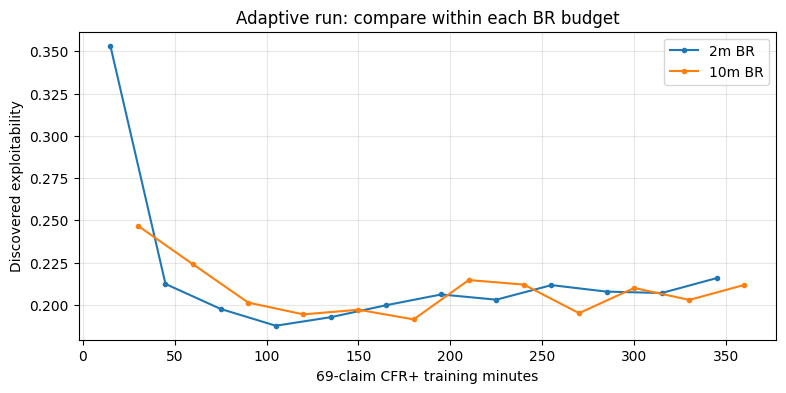

The old 60-minute BR and adaptive 2/10-minute BR values are not directly comparable.


In [11]:
old69 = ROOT / 'artifacts/cfr_plus_approx_reference_runs/r6_s4_h4_hp2ptfhq_ss___20260622-152749/approx_br_selected_60m/60m_summary.csv'
adaptive69 = ROOT / 'artifacts/cfr_plus_69_claim_adaptive/r6_s4_h4_hp2ptfhq_ss___20260628-095411/monitor_summary.jsonl'
if old69.exists():
    old = pd.read_csv(old69)
    display(old[['target min', 'responder training min', 'best discovered estimate', 'conservative lower bound']])
if adaptive69.exists():
    adaptive = read_jsonl(adaptive69)
    average = adaptive[adaptive['policy_kind'].eq('average')].copy()
    display(average[['measured_training_min', 'br_total_target_min', 'decision_estimate', 'phase_name']].tail(12))
    fig, ax = plt.subplots(figsize=(9, 4))
    for budget, group in average.groupby('br_total_target_min'):
        ax.plot(group['measured_training_min'], group['decision_estimate'], marker='.', label=f'{budget:g}m BR')
    ax.set(xlabel='69-claim CFR+ training minutes', ylabel='Discovered exploitability', title='Adaptive run: compare within each BR budget')
    ax.legend(); ax.grid(alpha=.3); plt.show()
print('The old 60-minute BR and adaptive 2/10-minute BR values are not directly comparable.')

## 5. What is actually available to continue?

The old 69-claim run's 400-minute snapshot was its best **60-minute-BR** observation (~0.282), but that intermediate policy is not in this local copy. The local saved 69-claim policies can be loaded for play and further BR evaluation. The adaptive and branch-fork `.pt` files copied to this machine appear truncated; a valid filename/size does not establish resumability. This lightweight check tests their ZIP container without loading gigabytes into memory. It does not repair them.

In [12]:
adaptive_run = ROOT / 'artifacts/cfr_plus_69_claim_adaptive/r6_s4_h4_hp2ptfhq_ss___20260628-095411'
branch_run = ROOT / 'artifacts/cfr_plus_69_claim_branch_forks/r6_s4_h4_hp2ptfhq_ss___20260628-232517'
checks = []
for run in (adaptive_run, branch_run):
    for checkpoint in sorted(run.rglob('*.pt')):
        checks.append({'run': run.parent.name, 'checkpoint': str(checkpoint.relative_to(ROOT)),
                       'GiB': round(checkpoint.stat().st_size / 2**30, 2),
                       'ZIP container valid': zipfile.is_zipfile(checkpoint)})
display(pd.DataFrame(checks))

,run,checkpoint,GiB,ZIP container valid
0,cfr_plus_69_claim_adaptive,artifacts\cfr_plus_69_claim_adaptive\r6_s4_h4_...,0.54,False
1,cfr_plus_69_claim_adaptive,artifacts\cfr_plus_69_claim_adaptive\r6_s4_h4_...,0.55,False
2,cfr_plus_69_claim_adaptive,artifacts\cfr_plus_69_claim_adaptive\r6_s4_h4_...,0.54,False
3,cfr_plus_69_claim_adaptive,artifacts\cfr_plus_69_claim_adaptive\r6_s4_h4_...,0.54,False
4,cfr_plus_69_claim_adaptive,artifacts\cfr_plus_69_claim_adaptive\r6_s4_h4_...,0.54,False
5,cfr_plus_69_claim_adaptive,artifacts\cfr_plus_69_claim_adaptive\r6_s4_h4_...,0.54,False
6,cfr_plus_69_claim_adaptive,artifacts\cfr_plus_69_claim_adaptive\r6_s4_h4_...,0.55,False
7,cfr_plus_69_claim_branch_forks,artifacts\cfr_plus_69_claim_branch_forks\r6_s4...,0.54,False
8,cfr_plus_69_claim_branch_forks,artifacts\cfr_plus_69_claim_branch_forks\r6_s4...,0.54,False
9,cfr_plus_69_claim_branch_forks,artifacts\cfr_plus_69_claim_branch_forks\r6_s4...,0.54,False


## Where to pick up

1. Re-read `core.py`, `env.py`, and `infoset.py` while running the hand above. Use `notebooks/` for focused validation examples.
2. Trace `CFRPlusDense.iterate()` and `best_response_exact()` on the tiny game; then read the saved 18-claim benchmark under `artifacts/benchmark_runs/`.
3. Trace `DeepCFRPlusTrainer.run_iteration()` into the GPU traverser and average network. `scripts/run_cfr_plus_69_claim_adaptive.py` shows the more recent training/controller workflow; `scripts/run_cfr_plus_69_claim_branch_forks.py` shows the later forks.
4. For any new 30/69-claim result, use a common, sufficiently long BR budget and multiple seeds before declaring improvement. The 69-claim game is **not solved**; the short-BR controller metric is useful for monitoring but can conceal stronger responses.
5. No valid local trainer checkpoint has been established for the 69-claim adaptive/fork runs. Resume only from a separately verified original checkpoint; otherwise start a new run from code or evaluate a saved policy.